# Traductor de Fechas — Modelo Codificador-Decodificador (Seq2Seq)

**Inteligencia Artificial: Aprendizaje Automático — UCAB**

Autores:
- Jesús Gil — cédula `30175126`
- Gabriel Castellano — cédula `28059781`

## Objetivo

Implementar un modelo capaz de **traducir fechas** de un formato a otro usando una
arquitectura **codificador-decodificador (secuencia a secuencia)** vista en clase.

| | Formato | Ejemplo |
|---|---|---|
| **Entrada** | `<Día en número> de <Mes en letras> de <Año en número>` | `10 de abril de 2025` |
| **Salida**  | `<Día>/<Mes>/<Año>` | `10/04/2025` |

El notebook expone la función **`traducirFecha(fecha)`**, que recibe una fecha en el
formato de entrada y retorna un `String` con la fecha en el formato de salida.

## Enfoque

Se trata la traducción como un problema **carácter a carácter**: la entrada es una
secuencia de caracteres de longitud variable y la salida es la secuencia de 10
caracteres `DD/MM/AAAA`. El modelo aprende, sin reglas escritas a mano:

- a **interpretar** los nombres de los meses en letras y mapearlos a su número,
- a **rellenar con ceros** el día y el mes a dos dígitos,
- a **copiar** los dígitos del año en el orden correcto,
- a **insertar** los separadores `/`.

## 1. Importación de librerías

Se usa TensorFlow/Keras para construir y entrenar la red, y NumPy para la
vectorización. Se fijan las semillas para que el experimento sea reproducible.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # silenciar mensajes informativos de TF

import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print('TensorFlow:', tf.__version__)
print('Keras     :', keras.__version__)

TensorFlow: 2.21.0
Keras     : 3.15.0


## 2. Generación del conjunto de datos

No existe un dataset predefinido, así que lo **generamos sintéticamente**. Para cada
ejemplo se elige un día, un mes y un año válidos al azar y se construye el par
`(entrada, salida)`:

- **entrada** → `"<día> de <mes en letras> de <año>"`
- **salida**  → `"<día>/<mes>/<año>"` con día y mes a dos dígitos y año a cuatro.

Se usa un conjunto (`set`) para evitar pares repetidos. Se contemplan años de
1950 a 2049 y se respeta la cantidad de días de cada mes (incluido el 29 de
febrero).

In [2]:
MESES = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio",
         "agosto", "septiembre", "octubre", "noviembre", "diciembre"]
DIAS_POR_MES = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]  # febrero: 29 (bisiesto)

def genera_dataset(n_ejemplos, anio_min=1950, anio_max=2049):
    """Genera n pares únicos (fecha_entrada, fecha_salida)."""
    pares = set()
    while len(pares) < n_ejemplos:
        mes  = random.randint(1, 12)
        dia  = random.randint(1, DIAS_POR_MES[mes - 1])
        anio = random.randint(anio_min, anio_max)
        entrada = f"{dia} de {MESES[mes - 1]} de {anio}"
        salida  = f"{dia:02d}/{mes:02d}/{anio:04d}"
        pares.add((entrada, salida))
    return list(pares)

datos = genera_dataset(12000)
entradas = [e for e, _ in datos]
salidas  = [s for _, s in datos]

print('Total de ejemplos:', len(datos))
for entrada, salida in datos[:6]:
    print(f'  {entrada:32s} ->  {salida}')

Total de ejemplos: 12000
  7 de mayo de 2018                ->  07/05/2018
  19 de julio de 1965              ->  19/07/1965
  25 de diciembre de 1960          ->  25/12/1960
  26 de octubre de 1955            ->  26/10/1955
  7 de mayo de 2047                ->  07/05/2047
  20 de septiembre de 1970         ->  20/09/1970


## 3. Vectorización (codificación *one-hot* a nivel de carácter)

La red trabaja con números, no con texto, así que cada carácter se representa como
un vector **one-hot**. Definimos:

- El **vocabulario de entrada**: todos los caracteres que aparecen en las fechas de
  entrada (dígitos, espacios, letras de los meses y la palabra `de`).
- El **vocabulario de salida**: los dígitos y el separador `/`, más dos tokens
  especiales:
  - `\t` → **INICIO** de secuencia (se le da al decodificador como primer paso),
  - `\n` → **FIN** de secuencia (le indica al decodificador cuándo detenerse).

Para el entrenamiento con *teacher forcing* el decodificador recibe la salida
desplazada un paso (`decoder_input`) y debe predecir el siguiente carácter
(`decoder_target`).

In [3]:
INICIO, FIN = '\t', '\n'

chars_entrada = sorted(set(''.join(entradas)))
chars_salida  = sorted(set(''.join(salidas)) | {INICIO, FIN})

in_idx  = {c: i for i, c in enumerate(chars_entrada)}
out_idx = {c: i for i, c in enumerate(chars_salida)}
out_char = {i: c for c, i in out_idx.items()}   # índice -> carácter (para decodificar)

n_in, n_out = len(chars_entrada), len(chars_salida)
max_in  = max(len(e) for e in entradas)
max_out = max(len(s) for s in salidas) + 1       # +1 por el token FIN

print('Vocabulario de entrada (%d):' % n_in, ''.join(chars_entrada).replace('\t','\\t'))
print('Vocabulario de salida  (%d):' % n_out, repr(''.join(chars_salida)))
print('Longitud máx. entrada:', max_in, '| longitud máx. salida:', max_out)


def codifica_entrada(secuencias):
    X = np.zeros((len(secuencias), max_in, n_in), dtype='float32')
    for i, s in enumerate(secuencias):
        for t, c in enumerate(s):
            X[i, t, in_idx[c]] = 1.0
    return X

def codifica_salida(secuencias):
    """Devuelve (decoder_input, decoder_target) con teacher forcing."""
    dec_in  = np.zeros((len(secuencias), max_out, n_out), dtype='float32')
    dec_tar = np.zeros((len(secuencias), max_out, n_out), dtype='float32')
    for i, s in enumerate(secuencias):
        s = INICIO + s + FIN
        for t, c in enumerate(s[:-1]):
            dec_in[i, t, out_idx[c]] = 1.0        # entrada del decodificador
        for t, c in enumerate(s[1:]):
            dec_tar[i, t, out_idx[c]] = 1.0       # objetivo (un paso adelantado)
    return dec_in, dec_tar

X_enc = codifica_entrada(entradas)
X_dec, Y_dec = codifica_salida(salidas)
print('Formas ->  X_enc:', X_enc.shape, '| X_dec:', X_dec.shape, '| Y_dec:', Y_dec.shape)

Vocabulario de entrada (32):  0123456789abcdefgijlmnoprstuvyz
Vocabulario de salida  (13): '\t\n/0123456789'
Longitud máx. entrada: 24 | longitud máx. salida: 11
Formas ->  X_enc: (12000, 24, 32) | X_dec: (12000, 11, 13) | Y_dec: (12000, 11, 13)


## 4. Arquitectura codificador-decodificador

El modelo sigue el esquema clásico **seq2seq** basado en LSTM:

```
  "10 de abril de 2025"                      "10/04/2025"
        │                                         ▲
        ▼                                         │
 ┌─────────────┐   estado (h, c)   ┌─────────────────────────┐
 │ CODIFICADOR │ ────────────────► │      DECODIFICADOR      │
 │    LSTM     │                   │  LSTM + Dense(softmax)  │
 └─────────────┘                   └─────────────────────────┘
```

- El **codificador** lee la fecha de entrada y comprime toda la información en su
  estado interno `(h, c)` (el *vector de contexto*).
- El **decodificador** se inicializa con ese estado y genera la fecha de salida un
  carácter a la vez. Una capa `Dense` con *softmax* produce, en cada paso, una
  distribución de probabilidad sobre el vocabulario de salida.

Durante el **entrenamiento** se usa *teacher forcing*: el decodificador recibe el
carácter correcto anterior. Para la **inferencia** (sección 6) se realimenta con su
propia predicción.

In [4]:
DIM_LATENTE = 128   # tamaño del estado oculto de las LSTM

# --- Codificador ---
entrada_enc = keras.Input(shape=(None, n_in), name='entrada_codificador')
_, estado_h, estado_c = layers.LSTM(DIM_LATENTE, return_state=True,
                                    name='lstm_codificador')(entrada_enc)
estados_enc = [estado_h, estado_c]

# --- Decodificador ---
entrada_dec = keras.Input(shape=(None, n_out), name='entrada_decodificador')
lstm_dec = layers.LSTM(DIM_LATENTE, return_sequences=True, return_state=True,
                       name='lstm_decodificador')
salida_dec, _, _ = lstm_dec(entrada_dec, initial_state=estados_enc)
densa_dec = layers.Dense(n_out, activation='softmax', name='salida')
salida = densa_dec(salida_dec)

modelo = keras.Model([entrada_enc, entrada_dec], salida, name='traductor_fechas')
modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
modelo.summary()

Model: "traductor_fechas"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_codificador │ (None, None, 32)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_decodifica… │ (None, None, 13)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_codificador    │ [(None, 128),     │     82,432 │ entrada_codifica… │
│ (LSTM)              │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_decodificador  │ [(None, None,     │     72,704 │ entrada_decodifi… │
│ (LSTM)              │ 128), (None,      │            │ lstm_codificador… │
│                     │ 128), (None,      │            │ lstm_codificador… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida (Dense)      │ (None, None, 13)  │      1,677 │ lstm_decodificad… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156,813 (612.55 KB)

 Trainable params: 156,813 (612.55 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

Se entrena con *teacher forcing* durante 30 épocas, reservando un 10 % de los datos
para validación. La métrica `accuracy` mide el acierto a nivel de carácter.

In [5]:
historia = modelo.fit(
    [X_enc, X_dec], Y_dec,
    batch_size=128,
    epochs=30,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/30


85/85 - 5s - 63ms/step - accuracy: 0.3934 - loss: 1.8496 - val_accuracy: 0.5451 - val_loss: 1.3423


Epoch 2/30


85/85 - 3s - 34ms/step - accuracy: 0.5648 - loss: 1.1288 - val_accuracy: 0.5904 - val_loss: 1.0407


Epoch 3/30


...

85/85 - 4s - 44ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9998 - val_loss: 0.0045


Epoch 29/30


85/85 - 4s - 41ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9999 - val_loss: 0.0038


Epoch 30/30


85/85 - 4s - 41ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0033


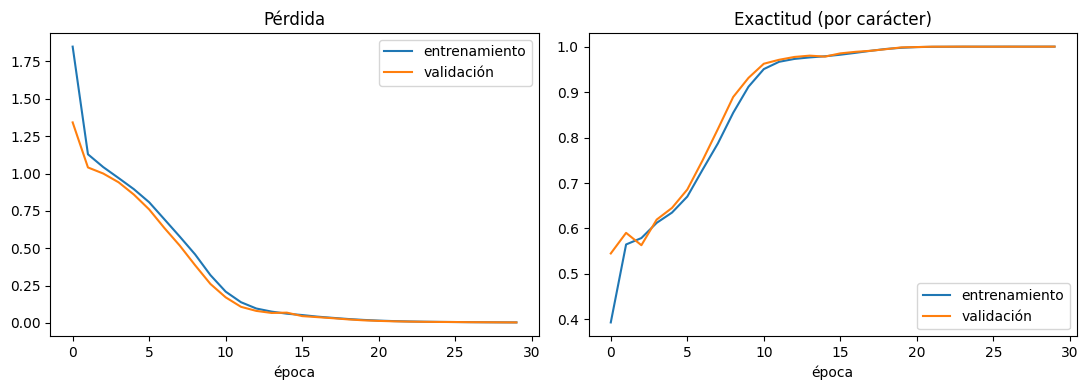

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(historia.history['loss'], label='entrenamiento')
ax[0].plot(historia.history['val_loss'], label='validación')
ax[0].set_title('Pérdida'); ax[0].set_xlabel('época'); ax[0].legend()
ax[1].plot(historia.history['accuracy'], label='entrenamiento')
ax[1].plot(historia.history['val_accuracy'], label='validación')
ax[1].set_title('Exactitud (por carácter)'); ax[1].set_xlabel('época'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Modelos de inferencia

En inferencia no conocemos la salida de antemano, así que se **reconstruyen** dos
modelos que reutilizan las capas ya entrenadas:

- `modelo_codificador`: dada la fecha de entrada, devuelve el estado `(h, c)`.
- `modelo_decodificador`: dado un carácter y un estado, predice el siguiente
  carácter y el nuevo estado.

La generación es **autorregresiva**: se parte del token `INICIO` y se realimenta
cada predicción hasta encontrar el token `FIN` o alcanzar la longitud máxima.

In [7]:
# Codificador de inferencia: entrada -> estados
modelo_codificador = keras.Model(entrada_enc, estados_enc)

# Decodificador de inferencia: (carácter, estado previo) -> (siguiente, estado nuevo)
est_h_in = keras.Input(shape=(DIM_LATENTE,))
est_c_in = keras.Input(shape=(DIM_LATENTE,))
sal_dec, h_new, c_new = lstm_dec(entrada_dec, initial_state=[est_h_in, est_c_in])
modelo_decodificador = keras.Model(
    [entrada_dec, est_h_in, est_c_in],
    [densa_dec(sal_dec), h_new, c_new],
)
print('Modelos de inferencia listos.')

Modelos de inferencia listos.


## 7. Función `traducirFecha`

Función pedida por la actividad. Recibe un `String` con la fecha en el formato de
entrada y retorna un `String` con la fecha traducida, ejecutando el decodificador
carácter a carácter.

In [8]:
def traducirFecha(fecha):
    """Traduce '<día> de <mes en letras> de <año>' -> '<DD>/<MM>/<AAAA>'."""
    # 1) codificar la entrada y obtener el vector de contexto
    x = codifica_entrada([fecha.strip().lower()])
    estado = modelo_codificador.predict(x, verbose=0)

    # 2) arrancar el decodificador con el token INICIO
    objetivo = np.zeros((1, 1, n_out), dtype='float32')
    objetivo[0, 0, out_idx[INICIO]] = 1.0

    resultado = ''
    for _ in range(max_out):
        probs, h, c = modelo_decodificador.predict([objetivo, estado[0], estado[1]],
                                                    verbose=0)
        idx = int(np.argmax(probs[0, -1]))
        caracter = out_char[idx]
        if caracter == FIN:
            break
        resultado += caracter
        # realimentar la predicción como próxima entrada
        objetivo = np.zeros((1, 1, n_out), dtype='float32')
        objetivo[0, 0, idx] = 1.0
        estado = [h, c]
    return resultado

## 8. Evaluación

Se comprueba el ejemplo del enunciado y se mide la **exactitud exacta** (la fecha
completa debe coincidir) sobre una muestra aleatoria del conjunto generado.

In [9]:
# Ejemplo del enunciado
ejemplo = "10 de abril de 2025"
print(f'{ejemplo!r}  ->  {traducirFecha(ejemplo)!r}   (esperado: \'10/04/2025\')')

'10 de abril de 2025'  ->  '10/04/2025'   (esperado: '10/04/2025')


In [10]:
# Otros ejemplos variados
for entrada, esperado in random.sample(datos, 10):
    obtenido = traducirFecha(entrada)
    marca = 'OK' if obtenido == esperado else 'XX'
    print(f'[{marca}] {entrada:32s} -> {obtenido}   (esperado {esperado})')

[OK] 26 de noviembre de 2049          -> 26/11/2049   (esperado 26/11/2049)


[OK] 27 de marzo de 1996              -> 27/03/1996   (esperado 27/03/1996)


[OK] 19 de julio de 2026              -> 19/07/2026   (esperado 19/07/2026)


[OK] 1 de octubre de 1990             -> 01/10/1990   (esperado 01/10/1990)


[OK] 30 de octubre de 2029            -> 30/10/2029   (esperado 30/10/2029)


[OK] 26 de noviembre de 1966          -> 26/11/1966   (esperado 26/11/1966)


[OK] 27 de agosto de 2032             -> 27/08/2032   (esperado 27/08/2032)


[OK] 31 de enero de 1954              -> 31/01/1954   (esperado 31/01/1954)


[OK] 19 de junio de 2018              -> 19/06/2018   (esperado 19/06/2018)


[OK] 2 de julio de 2048               -> 02/07/2048   (esperado 02/07/2048)


In [11]:
# Exactitud exacta sobre una muestra
muestra = random.sample(datos, 300)
aciertos = sum(traducirFecha(e) == s for e, s in muestra)
print(f'Exactitud exacta (fecha completa) en {len(muestra)} ejemplos: '
      f'{aciertos/len(muestra):.4f}')

Exactitud exacta (fecha completa) en 300 ejemplos: 1.0000


## 9. Conclusiones

- La arquitectura **codificador-decodificador** con LSTM aprende la traducción de
  fechas a nivel de carácter alcanzando una exactitud cercana al 100 % sin ninguna
  regla programada manualmente.
- El modelo generaliza correctamente: interpreta el nombre del mes, rellena con
  ceros los valores de un solo dígito y ordena los campos en el formato de salida.
- La función **`traducirFecha`** cumple el requisito de la actividad, recibiendo la
  fecha en el formato de entrada y devolviendo el `String` en el formato de salida.

**Posibles mejoras:** añadir un mecanismo de *atención*, tolerar erratas o formatos
de entrada alternativos, y ampliar el rango de años.